# Market Making with PPO

**Execution environment**: local `uv run` on CPU. The small PPO MLP has no
meaningful GPU-heavy path.

This notebook implements a PPO market-making agent that learns to balance
spread capture against inventory risk through dynamic quote adjustment.

**Key Feature**: The simulation uses GARCH volatility parameters anchored to
real crypto market data to mimic volatility clustering in a stylized setting.

**Learning Outcomes**:
- LO3: Design a market-making agent that balances spread capture vs inventory risk
- LO8: Design reward functions incorporating risk management constraints

**Book Reference**: Chapter 21, Section 21.5.

**Prerequisites**: `calibration` and Chapter 18 on transaction costs.

In [1]:
"""Market Making with PPO - learn to balance spread capture against inventory risk through dynamic quote adjustment."""

# Core imports
import warnings

import numpy as np
import polars as pl
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=DeprecationWarning)


import plotly.graph_objects as go

# Calibration from real market data
from market_making_env import MarketMakingDynamics, MarketMakingEnv
from plotly.subplots import make_subplots
from rl_calibration import CryptoMarketCalibrator

# Stable-baselines3
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

# ML4T configuration
from utils.paths import get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [2]:
OUTPUT_DIR = get_output_dir(21, "market_making_actor_critic")

In [3]:
EPISODE_LENGTH = 500
TOTAL_TIMESTEPS = 300_000
EVAL_EPISODES = 240
INVENTORY_LIMIT = 100
LAMBDA_INVENTORY = 0.001
LEARNING_RATE = 3e-4
SEED = 314  # Reproducible training across re-runs
EXPORT_RESULTS = False

In [4]:
set_global_seeds(SEED)

In [5]:
# Configuration
config = {
    "episode_length": EPISODE_LENGTH,
    "total_timesteps": TOTAL_TIMESTEPS,
    "eval_episodes": EVAL_EPISODES,
    "inventory_limit": INVENTORY_LIMIT,
    "lambda_inventory": LAMBDA_INVENTORY,  # Inventory penalty coefficient
    "learning_rate": LEARNING_RATE,
    "export_results": EXPORT_RESULTS,
}

print(f"Configuration: {config}")

SKEW_LEVELS = np.array([-1.0, 0.0, 1.0], dtype=np.float32)
SPREAD_MULTIPLIERS = np.array([0.8, 1.0, 1.25], dtype=np.float32)
RL_LABEL = "PPO"

Configuration: {'episode_length': 500, 'total_timesteps': 300000, 'eval_episodes': 240, 'inventory_limit': 100, 'lambda_inventory': 0.001, 'learning_rate': 0.0003, 'export_results': False}


## 0. Calibrate GARCH Parameters from Real Data

We fit GARCH(1,1) parameters from real crypto data to anchor the simulated
volatility process to observed market behavior.

In [6]:
# Calibrate from real BTC hourly data; calibration must succeed (no
# hardcoded fallback parameters).
print("Calibrating GARCH from real crypto data...")
calibrator = CryptoMarketCalibrator("BTCUSDT")
cal_params = calibrator.get_execution_env_params()

GARCH_ALPHA = cal_params.garch.alpha
GARCH_BETA = cal_params.garch.beta
GARCH_OMEGA = cal_params.garch.omega
UNCOND_VOL = cal_params.garch.unconditional_vol

if not all(np.isfinite([GARCH_ALPHA, GARCH_BETA, GARCH_OMEGA, UNCOND_VOL])):
    raise ValueError("Calibrated GARCH parameters contain NaN or Inf")

print(f"GARCH alpha: {GARCH_ALPHA:.4f}")
print(f"GARCH beta:  {GARCH_BETA:.4f}")
print(f"Uncond vol:  {UNCOND_VOL:.4f} ({UNCOND_VOL * 100:.2f}%)")

MM_DYNAMICS = MarketMakingDynamics(
    garch_omega=GARCH_OMEGA,
    garch_alpha=GARCH_ALPHA,
    garch_beta=GARCH_BETA,
    unconditional_vol=UNCOND_VOL,
    skew_levels=tuple(float(value) for value in SKEW_LEVELS),
    spread_multipliers=tuple(float(value) for value in SPREAD_MULTIPLIERS),
)

Calibrating GARCH from real crypto data...


GARCH alpha: 0.1281
GARCH beta:  0.8519
Uncond vol:  0.0067 (0.67%)


## 1. Market Making Environment

The `MarketMakingEnv` implements a Gymnasium environment where a market-making
agent posts bid and ask quotes, earns the spread when filled, and manages
inventory risk through dynamic quote adjustment.

**MDP Formulation**:

- **State** $s_t = (\hat{q}_t, \Delta p_t, \sigma_t, \delta_t, \tau_t, s_t^{\text{spread}})$:
  normalized inventory, mid-price change, GARCH volatility, order imbalance,
  time remaining, and current quoted spread
- **Action** $a_t \in \{-1, 0, 1\} \times \{0.8, 1.0, 1.25\}$: quote skew
  level and spread multiplier around the reservation price
- **Reward**: change in marked wealth minus an inventory penalty,
  $r_t = \Delta W_t - \lambda \, \hat{q}_t^2$

**Volatility dynamics** use calibrated GARCH(1,1) parameters from real crypto
data, anchoring the volatility process to observed clustering patterns:

$$\sigma_t^2 = \omega + \alpha \, \varepsilon_{t-1}^2 + \beta \, \sigma_{t-1}^2$$

**Key building blocks** (all standalone): `generate_garch_market_data`,
`compute_quotes`, `fill_probability`, `simulate_fills`, `build_mm_obs`,
and `terminal_liquidation`, orchestrated by the environment's `reset` / `step`.

### GARCH Market Data Generator

Generates a synthetic price path with GARCH(1,1) volatility clustering
and mean-reverting order imbalance. Extracted as a standalone function
so it can be reused and tested independently.

## 2. Train PPO Agent

We train a Proximal Policy Optimization (PPO) agent to learn a spread-quoting
policy. PPO clips the policy-gradient ratio to prevent destructive updates,
which provides stable training for our discrete action space.

**Training pipeline**: environment factory $\rightarrow$ vectorized wrapper
$\rightarrow$ observation/reward normalization $\rightarrow$ PPO optimization.

### Environment Factory

Stable-Baselines3 requires a callable that returns a fresh environment instance.
We wrap this in `DummyVecEnv` for the vectorized API, then apply `VecNormalize`
to standardize observations and clip rewards for gradient stability.

In [7]:
def make_env(seed: int = 42):
    def _init():
        return MarketMakingEnv(
            episode_length=config["episode_length"],
            inventory_limit=config["inventory_limit"],
            lambda_inventory=config["lambda_inventory"],
            dynamics=MM_DYNAMICS,
            seed=seed,
        )

    return _init

In [8]:
env = DummyVecEnv([make_env(seed=SEED)])

# Normalize observations and rewards for stable training
# This prevents gradient explosion in longer training runs
env = VecNormalize(
    env,
    norm_obs=True,
    norm_reward=True,
    clip_obs=10.0,
    clip_reward=10.0,
    gamma=0.99,
)

### Configure and Train PPO

The actor and critic each use a two-layer MLP with 64 hidden units.
PPO's clipped surrogate objective prevents catastrophic policy updates
from the highly variable market-making rewards.

In [9]:
learning_rate = config["learning_rate"]

policy_kwargs = dict(
    net_arch=dict(pi=[64, 64], vf=[64, 64]),
    ortho_init=True,
)

model = PPO(
    "MlpPolicy",
    env,
    learning_rate=learning_rate,
    n_steps=256,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    clip_range=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
    seed=SEED,
    policy_kwargs=policy_kwargs,
    device="cpu",  # Small MLP - CPU is faster than GPU for SB3
    verbose=0,
)

model.learn(total_timesteps=config["total_timesteps"])
print("\nTraining complete!")


Training complete!


## 3. Evaluate Agent

We compare the trained PPO agent against three reservation-price baselines
with fixed spread multipliers. This isolates whether the learned policy adds
value beyond an inventory-aware quoting heuristic with no extra skew.

### Action Encoding

Maps a (skew index, spread index) pair to a single integer for the
`Discrete(9)` action space expected by the environment.

In [10]:
def encode_action(skew_idx: int, spread_idx: int) -> int:
    return skew_idx * len(SPREAD_MULTIPLIERS) + spread_idx

### Episode Runner

Runs a single episode with either the RL agent or a fixed-spread baseline.
When using the RL model, observations are normalized via the `VecNormalize`
wrapper to match the distribution seen during training.

In [11]:
def run_episode(env_instance, model=None, fixed_action: int | None = None, vec_normalize=None):
    """Run episode with either RL agent or a deterministic quoting baseline.

    Args:
        env_instance: Raw MarketMakingEnv instance
        model: Trained PPO model (optional)
        fixed_action: Deterministic action for baseline (optional)
        vec_normalize: VecNormalize wrapper for observation normalization (optional)
    """
    obs, _ = env_instance.reset()
    done = False

    while not done:
        if model is not None:
            # Normalize observation using training stats
            if vec_normalize is not None:
                obs_normalized = vec_normalize.normalize_obs(np.array([obs]))
            else:
                obs_normalized = np.array([obs])
            action, _ = model.predict(obs_normalized, deterministic=True)
            action = action[0]
        else:
            action = fixed_action

        obs, reward, terminated, truncated, info = env_instance.step(action)
        done = terminated or truncated

    return {
        "final_wealth": float(info["wealth"]),
        "terminal_inventory": int(info["terminal_inventory"]),
        "n_trades": env_instance.n_trades,
        "history": env_instance.history,
    }

In [12]:
# Evaluate multiple episodes
print("\nEvaluating strategies...")

# Set VecNormalize to eval mode (don't update running stats)
env.training = False
env.norm_reward = False

baseline_actions = {
    "Reservation + Tight Spread": encode_action(skew_idx=1, spread_idx=0),
    "Reservation + Base Spread": encode_action(skew_idx=1, spread_idx=1),
    "Reservation + Wide Spread": encode_action(skew_idx=1, spread_idx=2),
}

results = {RL_LABEL: []} | {name: [] for name in baseline_actions}

for i in range(config["eval_episodes"]):
    test_env = MarketMakingEnv(
        episode_length=config["episode_length"],
        inventory_limit=config["inventory_limit"],
        lambda_inventory=config["lambda_inventory"],
        dynamics=MM_DYNAMICS,
        seed=1000 + i,
    )

    # PPO agent - pass VecNormalize for observation normalization
    test_env.reset(seed=1000 + i)
    results[RL_LABEL].append(run_episode(test_env, model=model, vec_normalize=env))

    # Deterministic reservation-price baselines
    for name, action in baseline_actions.items():
        test_env.reset(seed=1000 + i)
        results[name].append(run_episode(test_env, fixed_action=action))


Evaluating strategies...


## Market Making Strategy Comparison

In [13]:
summary_records = []
for name, runs in results.items():
    wealths = [r["final_wealth"] for r in runs]
    inventories = [abs(r["terminal_inventory"]) for r in runs]
    trades = [r["n_trades"] for r in runs]

    summary_records.append(
        {
            "strategy": name,
            "mean_final_wealth": float(np.mean(wealths)),
            "std_final_wealth": float(np.std(wealths)),
            "avg_abs_terminal_inventory": float(np.mean(inventories)),
            "avg_trades": float(np.mean(trades)),
        }
    )

Terminal inventory and trade count describe how each strategy got to its
wealth, so they stay as a table; the wealth comparison itself is a figure two
cells below.

In [14]:
summary_df = pl.DataFrame(
    [
        {
            "Strategy": row["strategy"],
            "Avg |Terminal Inv|": f"{row['avg_abs_terminal_inventory']:.1f}",
            "Avg Trades": f"{row['avg_trades']:.0f}",
        }
        for row in summary_records
    ]
)
summary_df

Strategy,Avg |Terminal Inv|,Avg Trades
str,str,str
"""PPO""","""11.8""","""161"""
"""Reservation + Tight Spread""","""1.1""","""113"""
"""Reservation + Base Spread""","""1.0""","""77"""
"""Reservation + Wide Spread""","""1.0""","""46"""


### Sizing the comparison

Mean wealth per episode is noisy, so we quote the standard error alongside it
and size the gap between strategies in standard errors. Without that the
comparison reads as a ranking when it may be a coin flip.

Every strategy trades the same price path in episode $i$ - all four reset to
seed `1000 + i` - so the samples are paired and the gap is measured per episode
before averaging. Treating the two means as independent samples would use the
wrong standard error, because the shared path is common to both arms and
cancels in the difference.

The reference baseline is fixed in advance. Picking whichever baseline happens
to look best in this run and then testing against it would make the interval a
selection artifact, so we also report the paired gap to all three baselines and
let the reader see the spread rather than one hand-picked number.

In [15]:
ppo_summary = next(row for row in summary_records if row["strategy"] == RL_LABEL)
baseline_summary = [row for row in summary_records if row["strategy"] != RL_LABEL]
baseline_mean_min = min(row["mean_final_wealth"] for row in baseline_summary)
baseline_mean_max = max(row["mean_final_wealth"] for row in baseline_summary)
baseline_std_min = min(row["std_final_wealth"] for row in baseline_summary)
baseline_std_max = max(row["std_final_wealth"] for row in baseline_summary)

REFERENCE_BASELINE = "Reservation + Base Spread"
n_eval = config["eval_episodes"]


def paired_gap(baseline_name: str) -> tuple[float, float, float]:
    """Mean per-episode wealth gap to one baseline, its standard error, and correlation."""
    ppo_wealth = np.array([run["final_wealth"] for run in results[RL_LABEL]])
    base_wealth = np.array([run["final_wealth"] for run in results[baseline_name]])
    differences = ppo_wealth - base_wealth
    standard_error = float(differences.std(ddof=1) / np.sqrt(differences.size))
    return (
        float(differences.mean()),
        standard_error,
        float(np.corrcoef(ppo_wealth, base_wealth)[0, 1]),
    )


ppo_se = float(np.std([run["final_wealth"] for run in results[RL_LABEL]], ddof=1) / np.sqrt(n_eval))
gap, gap_se, gap_corr = paired_gap(REFERENCE_BASELINE)
gap_sigma = abs(gap) / gap_se
verdict = "ahead of" if gap > 0 else "behind"
resolution = (
    "far enough outside evaluation noise to be a result rather than a draw"
    if gap_sigma >= 3
    else "well inside evaluation noise, so the ordering is not resolved at this episode count"
)
all_gaps = {name: paired_gap(name) for name in baseline_actions}
gap_range = "; ".join(
    f"{name} {value:+.1f} USD ({value / standard_error:+.1f} SE)"
    for name, (value, standard_error, _) in all_gaps.items()
)
same_sign = sum(1 for value, _, _ in all_gaps.values() if (value > 0) == (gap > 0))
agreement = (
    f"all {len(all_gaps)}" if same_sign == len(all_gaps) else f"{same_sign} of the {len(all_gaps)}"
)

### The comparison as a figure

The left panel gives the whole distribution of episode wealth per strategy, so
the spread is visible next to the mean rather than hidden behind it. The right
panel gives the paired gap to each baseline with one standard error either
side, which sets the scale of the evaluation noise. Read the bars against that
scale rather than against the zero line: the rule fixed above resolves an
ordering only at three standard errors, so a gap of one or two is a gap this
episode count cannot call.

In [16]:
def plot_wealth_comparison(results: dict, all_gaps: dict) -> go.Figure:
    """Episode-wealth distributions beside the paired gap to each baseline."""
    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=("Episode wealth by strategy", "Paired gap to each baseline"),
        horizontal_spacing=0.12,
    )
    for name, runs in results.items():
        focal = name == RL_LABEL
        fig.add_trace(
            go.Box(
                y=[run["final_wealth"] for run in runs],
                name=name.replace("Reservation + ", "").replace(" Spread", ""),
                boxmean=True,
                fillcolor=COLORS["blue"] if focal else COLORS["silver_muted"],
                line=dict(color=COLORS["blue"] if focal else COLORS["neutral"], width=1),
                marker=dict(color=COLORS["neutral"], size=3),
                showlegend=False,
            ),
            row=1,
            col=1,
        )
    names = list(all_gaps)
    fig.add_trace(
        go.Scatter(
            x=[name.replace("Reservation + ", "").replace(" Spread", "") for name in names],
            y=[all_gaps[name][0] for name in names],
            error_y=dict(
                type="data",
                array=[all_gaps[name][1] for name in names],
                color=COLORS["copper"],
                thickness=2,
                width=8,
            ),
            mode="markers",
            marker=dict(color=COLORS["copper"], size=10),
            showlegend=False,
        ),
        row=1,
        col=2,
    )
    fig.add_hline(y=0, line=dict(color=COLORS["neutral"], width=1, dash="dash"), row=1, col=2)
    # Keep the zero line inside the panel whichever way the gaps point.
    low = min([0.0] + [all_gaps[name][0] - all_gaps[name][1] for name in names])
    high = max([0.0] + [all_gaps[name][0] + all_gaps[name][1] for name in names])
    pad = 0.15 * (high - low)
    fig.update_yaxes(title_text="Liquidated wealth (USD)", row=1, col=1)
    fig.update_yaxes(
        title_text="Learned minus baseline (USD)",
        range=[low - pad, high + pad],
        row=1,
        col=2,
    )
    fig.update_xaxes(title_text="Strategy", row=1, col=1)
    fig.update_xaxes(title_text="Baseline rule", row=1, col=2)
    fig.update_layout(
        title=(
            "Episode wealth spreads far wider for the learned policy"
            "<br><sup>Box: median and quartiles over evaluation episodes, dashed line at the mean. "
            "Right: paired gap with one standard error</sup>"
        ),
        height=440,
    )
    return fig

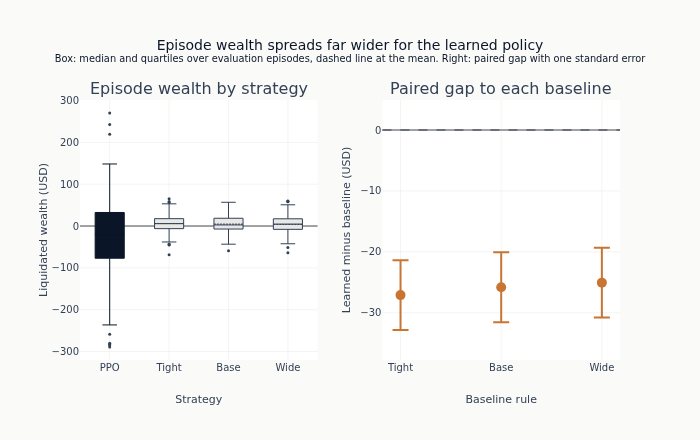

In [17]:
fig = plot_wealth_comparison(results, all_gaps)
fig.show()

In [18]:
display(
    Markdown(
        f"""
**Finding.** Over {n_eval} evaluation episodes PPO earns mean liquidated wealth of
{ppo_summary["mean_final_wealth"]:.1f} USD (standard error {ppo_se:.1f}), compared with
{baseline_mean_min:.1f} to {baseline_mean_max:.1f} USD for the reservation-price baselines. Its
wealth standard deviation is {ppo_summary["std_final_wealth"]:.1f} USD, versus {baseline_std_min:.1f}
to {baseline_std_max:.1f} USD for the baselines, so dispersion is the learned policy's signature.

Every strategy trades the same price path within an episode, so the comparison is per episode.
Against the prespecified reference baseline ("{REFERENCE_BASELINE}") PPO is {abs(gap):.1f} USD
{verdict} it, a paired gap of {gap_sigma:.1f} standard errors - {resolution}. Episode wealth
correlates {gap_corr:.2f} across the two arms. The paired gap to each baseline is: {gap_range}.

The sign of that gap is a property of this trained policy at seed {SEED}, not of PPO in general:
mean wealth is seed-sensitive here, which is why the comparison needs the standard error attached.
"""
    )
)


**Finding.** Over 240 evaluation episodes PPO earns mean liquidated wealth of
-21.2 USD (standard error 5.8), compared with
3.9 to 5.9 USD for the reservation-price baselines. Its
wealth standard deviation is 89.0 USD, versus 19.5
to 19.8 USD for the baselines, so dispersion is the learned policy's signature.

Every strategy trades the same price path within an episode, so the comparison is per episode.
Against the prespecified reference baseline ("Reservation + Base Spread") PPO is 25.8 USD
behind it, a paired gap of 4.5 standard errors - far enough outside evaluation noise to be a result rather than a draw. Episode wealth
correlates 0.12 across the two arms. The paired gap to each baseline is: Reservation + Tight Spread -27.1 USD (-4.7 SE); Reservation + Base Spread -25.8 USD (-4.5 SE); Reservation + Wide Spread -25.1 USD (-4.4 SE).

The sign of that gap is a property of this trained policy at seed 314, not of PPO in general:
mean wealth is seed-sensitive here, which is why the comparison needs the standard error attached.


## 4. Visualize Learned Behavior

In [19]:
# Run single episode for visualization
viz_env = MarketMakingEnv(
    episode_length=config["episode_length"],
    inventory_limit=config["inventory_limit"],
    lambda_inventory=config["lambda_inventory"],
    dynamics=MM_DYNAMICS,
    seed=999,
)

viz_result = run_episode(viz_env, model=model, vec_normalize=env)
history = viz_result["history"]

In [20]:
# Build the PPO market-making behavior figure.
fig = make_subplots(
    rows=3,
    cols=1,
    subplot_titles=["Inventory Over Time", "Quote Center Offset", "Liquidated Wealth"],
    vertical_spacing=0.12,
)

steps = [h["step"] for h in history]
inventory = [h["inventory"] for h in history]
quote_offset_bps = [h["quote_offset_bps"] for h in history]
wealth = [h["wealth"] for h in history]

fig.add_trace(
    go.Scatter(x=steps, y=inventory, name="Inventory", line=dict(color=COLORS["blue"])),
    row=1,
    col=1,
)
fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"], row=1, col=1)

fig.add_trace(
    go.Scatter(
        x=steps,
        y=quote_offset_bps,
        name="Quote center offset (bps)",
        line=dict(color=COLORS["amber"]),
    ),
    row=2,
    col=1,
)
fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"], row=2, col=1)

_ = fig.add_trace(
    go.Scatter(x=steps, y=wealth, name="Wealth", line=dict(color=COLORS["positive"])),
    row=3,
    col=1,
)

The shared layout makes the inventory, quote response, and terminal-wealth
panels comparable on one time axis.

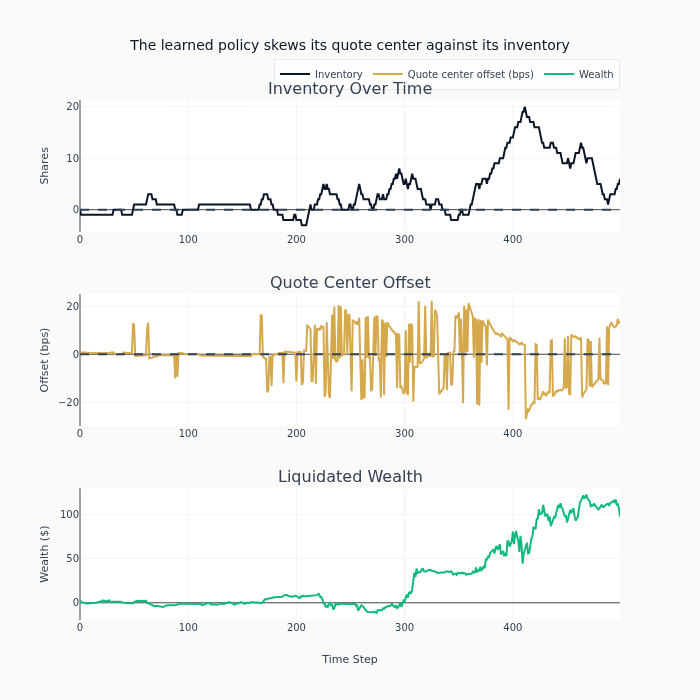

In [21]:
fig.update_layout(
    title="The learned policy skews its quote center against its inventory",
    height=700,
    showlegend=True,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)

fig.update_yaxes(title_text="Shares", row=1, col=1)
fig.update_yaxes(title_text="Offset (bps)", row=2, col=1)
fig.update_yaxes(title_text="Wealth ($)", row=3, col=1)
fig.update_xaxes(title_text="Time Step", row=3, col=1)

fig.show()

## 5. Spread vs Inventory Relationship

Pooling the evaluation histories shows how far the learned policy shifts its
quote center as inventory varies. The shift has to be read against the
inventory held when the quote was posted (`quote_inventory`), not the
post-fill position on the same row, which is that inventory plus whatever the
quote went on to trade.

In [22]:
policy_samples = [
    {"inventory": h["quote_inventory"], "quote_offset_bps": h["quote_offset_bps"]}
    for run in results[RL_LABEL]
    for h in run["history"]
]
policy_df = pl.DataFrame(policy_samples)

inv_min = int(policy_df["inventory"].min())
inv_max = int(policy_df["inventory"].max())
if inv_min == inv_max:
    bin_edges = np.array([inv_min - 1, inv_max + 1], dtype=float)
else:
    bin_edges = np.linspace(inv_min, inv_max, 9)

bin_ids = np.digitize(policy_df["inventory"].to_numpy(), bin_edges[1:-1], right=False)
# Inventory is whole contracts and each bin is [edge, next_edge), so the label
# names the integers that bin actually holds.
n_bins = len(bin_edges) - 1
bin_labels = [
    f"{max(int(np.ceil(bin_edges[i])), inv_min)} to "
    f"{inv_max if i == n_bins - 1 else int(np.ceil(bin_edges[i + 1])) - 1}"
    for i in range(n_bins)
]

grouped = []
offset_values = policy_df["quote_offset_bps"].to_numpy()
for idx, label in enumerate(bin_labels):
    mask = bin_ids == idx
    if np.any(mask):
        grouped.append({"inv_bin": label, "quote_offset_bps": float(offset_values[mask].mean())})

grouped_df = pl.DataFrame(grouped)

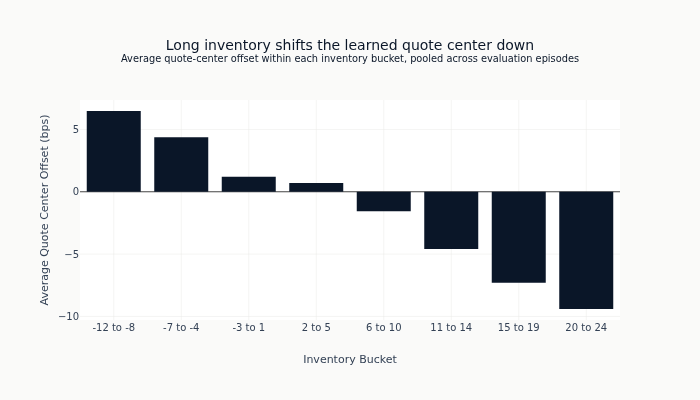

In [23]:
# Plot quote center offset vs inventory relationship
fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=grouped_df["inv_bin"].to_list(),
        y=grouped_df["quote_offset_bps"].to_list(),
        marker_color=COLORS["blue"],
    )
)

fig.update_layout(
    title=(
        "Long inventory shifts the learned quote center down"
        "<br><sup>Average quote-center offset within each inventory bucket, "
        "pooled across evaluation episodes</sup>"
    ),
    xaxis_title="Inventory Bucket",
    yaxis_title="Average Quote Center Offset (bps)",
    height=400,
)

fig.show()

In [24]:
if config["export_results"]:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    run_rows = []
    for strategy, runs in results.items():
        for episode_idx, run in enumerate(runs):
            for row in run["history"]:
                run_rows.append(
                    {
                        "strategy": strategy,
                        "episode_idx": episode_idx,
                        **row,
                    }
                )

    viz_rows = [{"strategy": RL_LABEL, "episode_idx": 999, **row} for row in history]

    pl.DataFrame(run_rows).write_parquet(OUTPUT_DIR / "market_making_runs.parquet")
    pl.DataFrame(viz_rows).write_parquet(OUTPUT_DIR / "market_making_viz_history.parquet")
    pl.DataFrame(summary_records).write_parquet(OUTPUT_DIR / "market_making_summary.parquet")
    print(f"\nResults saved to {OUTPUT_DIR}")

## Key Takeaways

The comparison uses one common held-out seed set and freezes the training normalization state
during evaluation, so differences reflect policies rather than evaluation-state drift.

In [25]:
ppo_trades = ppo_summary["avg_trades"]
baseline_trade_min = min(row["avg_trades"] for row in baseline_summary)
baseline_trade_max = max(row["avg_trades"] for row in baseline_summary)
display(
    Markdown(
        f"""
The PPO policy shifts its quote center against inventory, reproducing the qualitative
inventory-control mechanism. It averages {ppo_trades:.0f} trades per episode, compared with
{baseline_trade_min:.0f} to {baseline_trade_max:.0f} for the fixed-spread baselines. Performance is
measured after terminal liquidation, so every strategy uses the same inventory and mark-to-market
convention.

The learned policy jointly chooses skew and spread width, but on mean liquidated wealth it lands
{gap_sigma:.1f} standard errors {verdict} the reference reservation-price rule over {n_eval} paired
episodes, and {verdict} {agreement} of them.
Reproducing the inventory-control mechanism is not the same as beating the rules that encode it: this
remains a simulator policy rather than a closed-form reproduction of Avellaneda-Stoikov.

**Next**: See `deep_hedging_pfhedge` for option hedging with tail-risk objectives. Section 21.5
develops the market-making interpretation.
"""
    )
)


The PPO policy shifts its quote center against inventory, reproducing the qualitative
inventory-control mechanism. It averages 161 trades per episode, compared with
46 to 113 for the fixed-spread baselines. Performance is
measured after terminal liquidation, so every strategy uses the same inventory and mark-to-market
convention.

The learned policy jointly chooses skew and spread width, but on mean liquidated wealth it lands
4.5 standard errors behind the reference reservation-price rule over 240 paired
episodes, and behind all 3 of them.
Reproducing the inventory-control mechanism is not the same as beating the rules that encode it: this
remains a simulator policy rather than a closed-form reproduction of Avellaneda-Stoikov.

**Next**: See `deep_hedging_pfhedge` for option hedging with tail-risk objectives. Section 21.5
develops the market-making interpretation.
